In [42]:
import pandas as pd
import os 
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.tree import plot_tree
from sklearn.inspection import permutation_importance
from pgmpy.estimators import DiscreteMLE 
from pgmpy.inference import VariableElimination

ImportError: cannot import name 'DiscreteMLE' from 'pgmpy.estimators' (/home/mateus/Documents/Genetica/.venv/lib/python3.14/site-packages/pgmpy/estimators/__init__.py)

In [8]:
df = pd.read_csv('../banco_fenotipos_conformal.csv') # Load the phenotypic data
df = df.drop(columns=['id','samplefilename', 'CP1','CP2','CP3','CP4','CP5','CP6']) # remove the id from the table
colunas_categoricas = ['fumo', 'raca_cor', 'conjugal3', 'trabalho2', 'bebem2']
df = pd.get_dummies(df, columns=colunas_categoricas, drop_first=True, dtype=int) # Turns the categorical columns into 0 and 1
colunas_categoricas = [coluna for coluna in df.columns if df[coluna].nunique() < 6]

In [9]:
colunas_categoricas

['sexo',
 'faixa_etaria',
 'imc_cat4_aferido',
 'imc_cat_aferido',
 'ep',
 'obesidade',
 'obes_central',
 'cc_estat_cat',
 'medDM_bioq',
 'diabetes2',
 'HOMA_cat',
 'medHAS_bioq',
 'has2',
 'colnaohdl_cat',
 'fumo_fumante',
 'fumo_nunca',
 'fumo_não respondeu',
 'raca_cor_branca',
 'raca_cor_indígena',
 'raca_cor_não respondeu',
 'raca_cor_outras',
 'raca_cor_parda',
 'raca_cor_preta',
 'conjugal3_casado/un. estavel',
 'conjugal3_separado/desq/divorc',
 'conjugal3_solteiro',
 'conjugal3_viuvo',
 'trabalho2_estudante',
 'trabalho2_nÃ£o trabalha',
 'trabalho2_trabalha',
 'bebem2_NS/NR',
 'bebem2_atÃ© 3x semana',
 'bebem2_nÃ£o bebe']

In [4]:
nrespondeu = [coluna for coluna in df.columns if 'respondeu' in coluna]
df = df.drop(columns=nrespondeu)

In [36]:
def extrair_frequencia_estabilidade_grafo(
    df, alvos, num_trees=500, iteracoes=50, fracao_amostra=0.5, q=3
):
    """Extrai a frequência de estabilidade das arestas baseado no artigo

    Fellinghauer et al. (2013).

    Parâmetros:
    - q: Número de top variáveis com maior importância que serão selecionadas
         em cada iteração (frequência binária).
    """
    # Matriz inicializada com zeros
    matriz_estabilidade = pd.DataFrame(
        index=alvos, columns=df.columns, dtype=np.float64
    ).fillna(0.0)

    for target in alvos:
        print(f"Rodando a variável {target}")
        df_alvo = df.dropna(subset=[target])

        for i in range(iteracoes):
            if fracao_amostra > 1:
                df_sub = df_alvo.sample(n=fracao_amostra, random_state=i)
            else:
                df_sub = df_alvo.sample(frac=fracao_amostra, random_state=i)
            

            X = df_sub.drop(columns=[target])
            y = df_sub[target]

            if target not in colunas_categoricas:
                modelorf = RandomForestRegressor(
                    n_estimators=num_trees,
                    max_features=0.3,
                    max_depth=8,
                    n_jobs = -1,
                    bootstrap=False,
                )
            else:
                modelorf = RandomForestClassifier(
                    n_estimators=num_trees,
                    max_features=0.3,
                    max_depth=8,
                    class_weight='balanced',
                    bootstrap=False, # Bootstrap ligado e 1 iteracao, e 100% dos dados
                    n_jobs = -1,
                )

            modelorf.fit(X, y)

            resultado_permutacao = permutation_importance(
                modelorf, X, y, n_repeats=3, random_state=i, n_jobs=-1
            )
            importancias = resultado_permutacao.importances_mean

            importancias_series = pd.Series(importancias, index=X.columns)

            top_q_variaveis = importancias_series.nlargest(q).index

            matriz_estabilidade.loc[target, top_q_variaveis] += 1.0

        matriz_estabilidade.loc[target] = (
            matriz_estabilidade.loc[target] / iteracoes
        )

    return matriz_estabilidade

In [37]:
%%time
# --- CÁLCULO DO LIMIAR DO ARTIGO ---
p = len(df.columns)  # Número total de variáveis no seu dataset
P = (p * (p - 1)) / 2  # Total de arestas possíveis em um grafo NÃO-DIRECIONADO
EV = 1# Número esperado de falsos positivos que você tolera no grafo todo


IMPORT_MIN = 0.6

q= int(np.sqrt((2*IMPORT_MIN -1) * EV * P))
print(q)
matriz_import = extrair_frequencia_estabilidade_grafo(df, df.columns, 100, 20,100,q)


13
Rodando a variável hb_g_dl
Rodando a variável glicose_mg_dl
Rodando a variável sexo
Rodando a variável idade
Rodando a variável faixa_etaria
Rodando a variável imc
Rodando a variável imc_cat4_aferido
Rodando a variável imc_cat_aferido
Rodando a variável ep
Rodando a variável obesidade
Rodando a variável ccm
Rodando a variável obes_central
Rodando a variável cc_estat
Rodando a variável cc_estat_cat
Rodando a variável medDM_bioq
Rodando a variável diabetes2
Rodando a variável HOMA_IR
Rodando a variável HOMA_cat
Rodando a variável pas_final
Rodando a variável pad_final
Rodando a variável medHAS_bioq
Rodando a variável has2
Rodando a variável col_nao_hdlc_mg_dl
Rodando a variável colnaohdl_cat
Rodando a variável fumo_fumante
Rodando a variável fumo_nunca
Rodando a variável fumo_não respondeu
Rodando a variável raca_cor_branca
Rodando a variável raca_cor_indígena
Rodando a variável raca_cor_não respondeu
Rodando a variável raca_cor_outras
Rodando a variável raca_cor_parda
Rodando a variá

In [38]:
matriz_numpy = matriz_import.to_numpy()

matriz_min = np.minimum(matriz_numpy,matriz_numpy.T)

matriz_final = pd.DataFrame(
    matriz_min, index=matriz_import.index, columns=matriz_import.columns
)

In [39]:
matriz_final

,hb_g_dl,glicose_mg_dl,sexo,idade,faixa_etaria,imc,imc_cat4_aferido,imc_cat_aferido,ep,obesidade,...,conjugal3_casado/un. estavel,conjugal3_separado/desq/divorc,conjugal3_solteiro,conjugal3_viuvo,trabalho2_estudante,trabalho2_nÃ£o trabalha,trabalho2_trabalha,bebem2_NS/NR,bebem2_atÃ© 3x semana,bebem2_nÃ£o bebe
hb_g_dl,0.00,0.70,0.95,0.45,0.15,0.65,0.20,0.05,0.00,0.00,...,0.10,0.20,0.05,0.15,0.00,0.00,0.30,0.00,0.15,0.10
glicose_mg_dl,0.70,0.00,0.20,0.75,0.35,0.60,0.20,0.00,0.00,0.00,...,0.05,0.00,0.25,0.10,0.00,0.00,0.10,0.00,0.00,0.05
sexo,0.95,0.20,0.00,0.00,1.00,0.00,1.00,1.00,1.00,0.85,...,0.05,0.00,0.00,0.10,0.00,0.00,0.00,0.00,0.00,0.00
idade,0.45,0.75,0.00,0.00,1.00,0.90,1.00,0.00,0.00,0.00,...,0.00,0.00,0.75,0.10,0.55,0.90,0.70,0.00,0.05,0.00
faixa_etaria,0.15,0.35,1.00,1.00,0.00,0.00,1.00,1.00,1.00,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
imc,0.65,0.60,0.00,0.90,0.00,0.00,1.00,1.00,1.00,1.00,...,0.00,0.25,0.00,0.00,0.00,0.00,0.05,0.00,0.00,0.00
imc_cat4_aferido,0.20,0.20,1.00,1.00,1.00,1.00,0.00,1.00,1.00,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
imc_cat_aferido,0.05,0.00,1.00,0.00,1.00,1.00,1.00,0.00,1.00,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
ep,0.00,0.00,1.00,0.00,1.00,1.00,1.00,1.00,0.00,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
obesidade,0.00,0.00,0.85,0.00,1.00,1.00,1.00,1.00,1.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


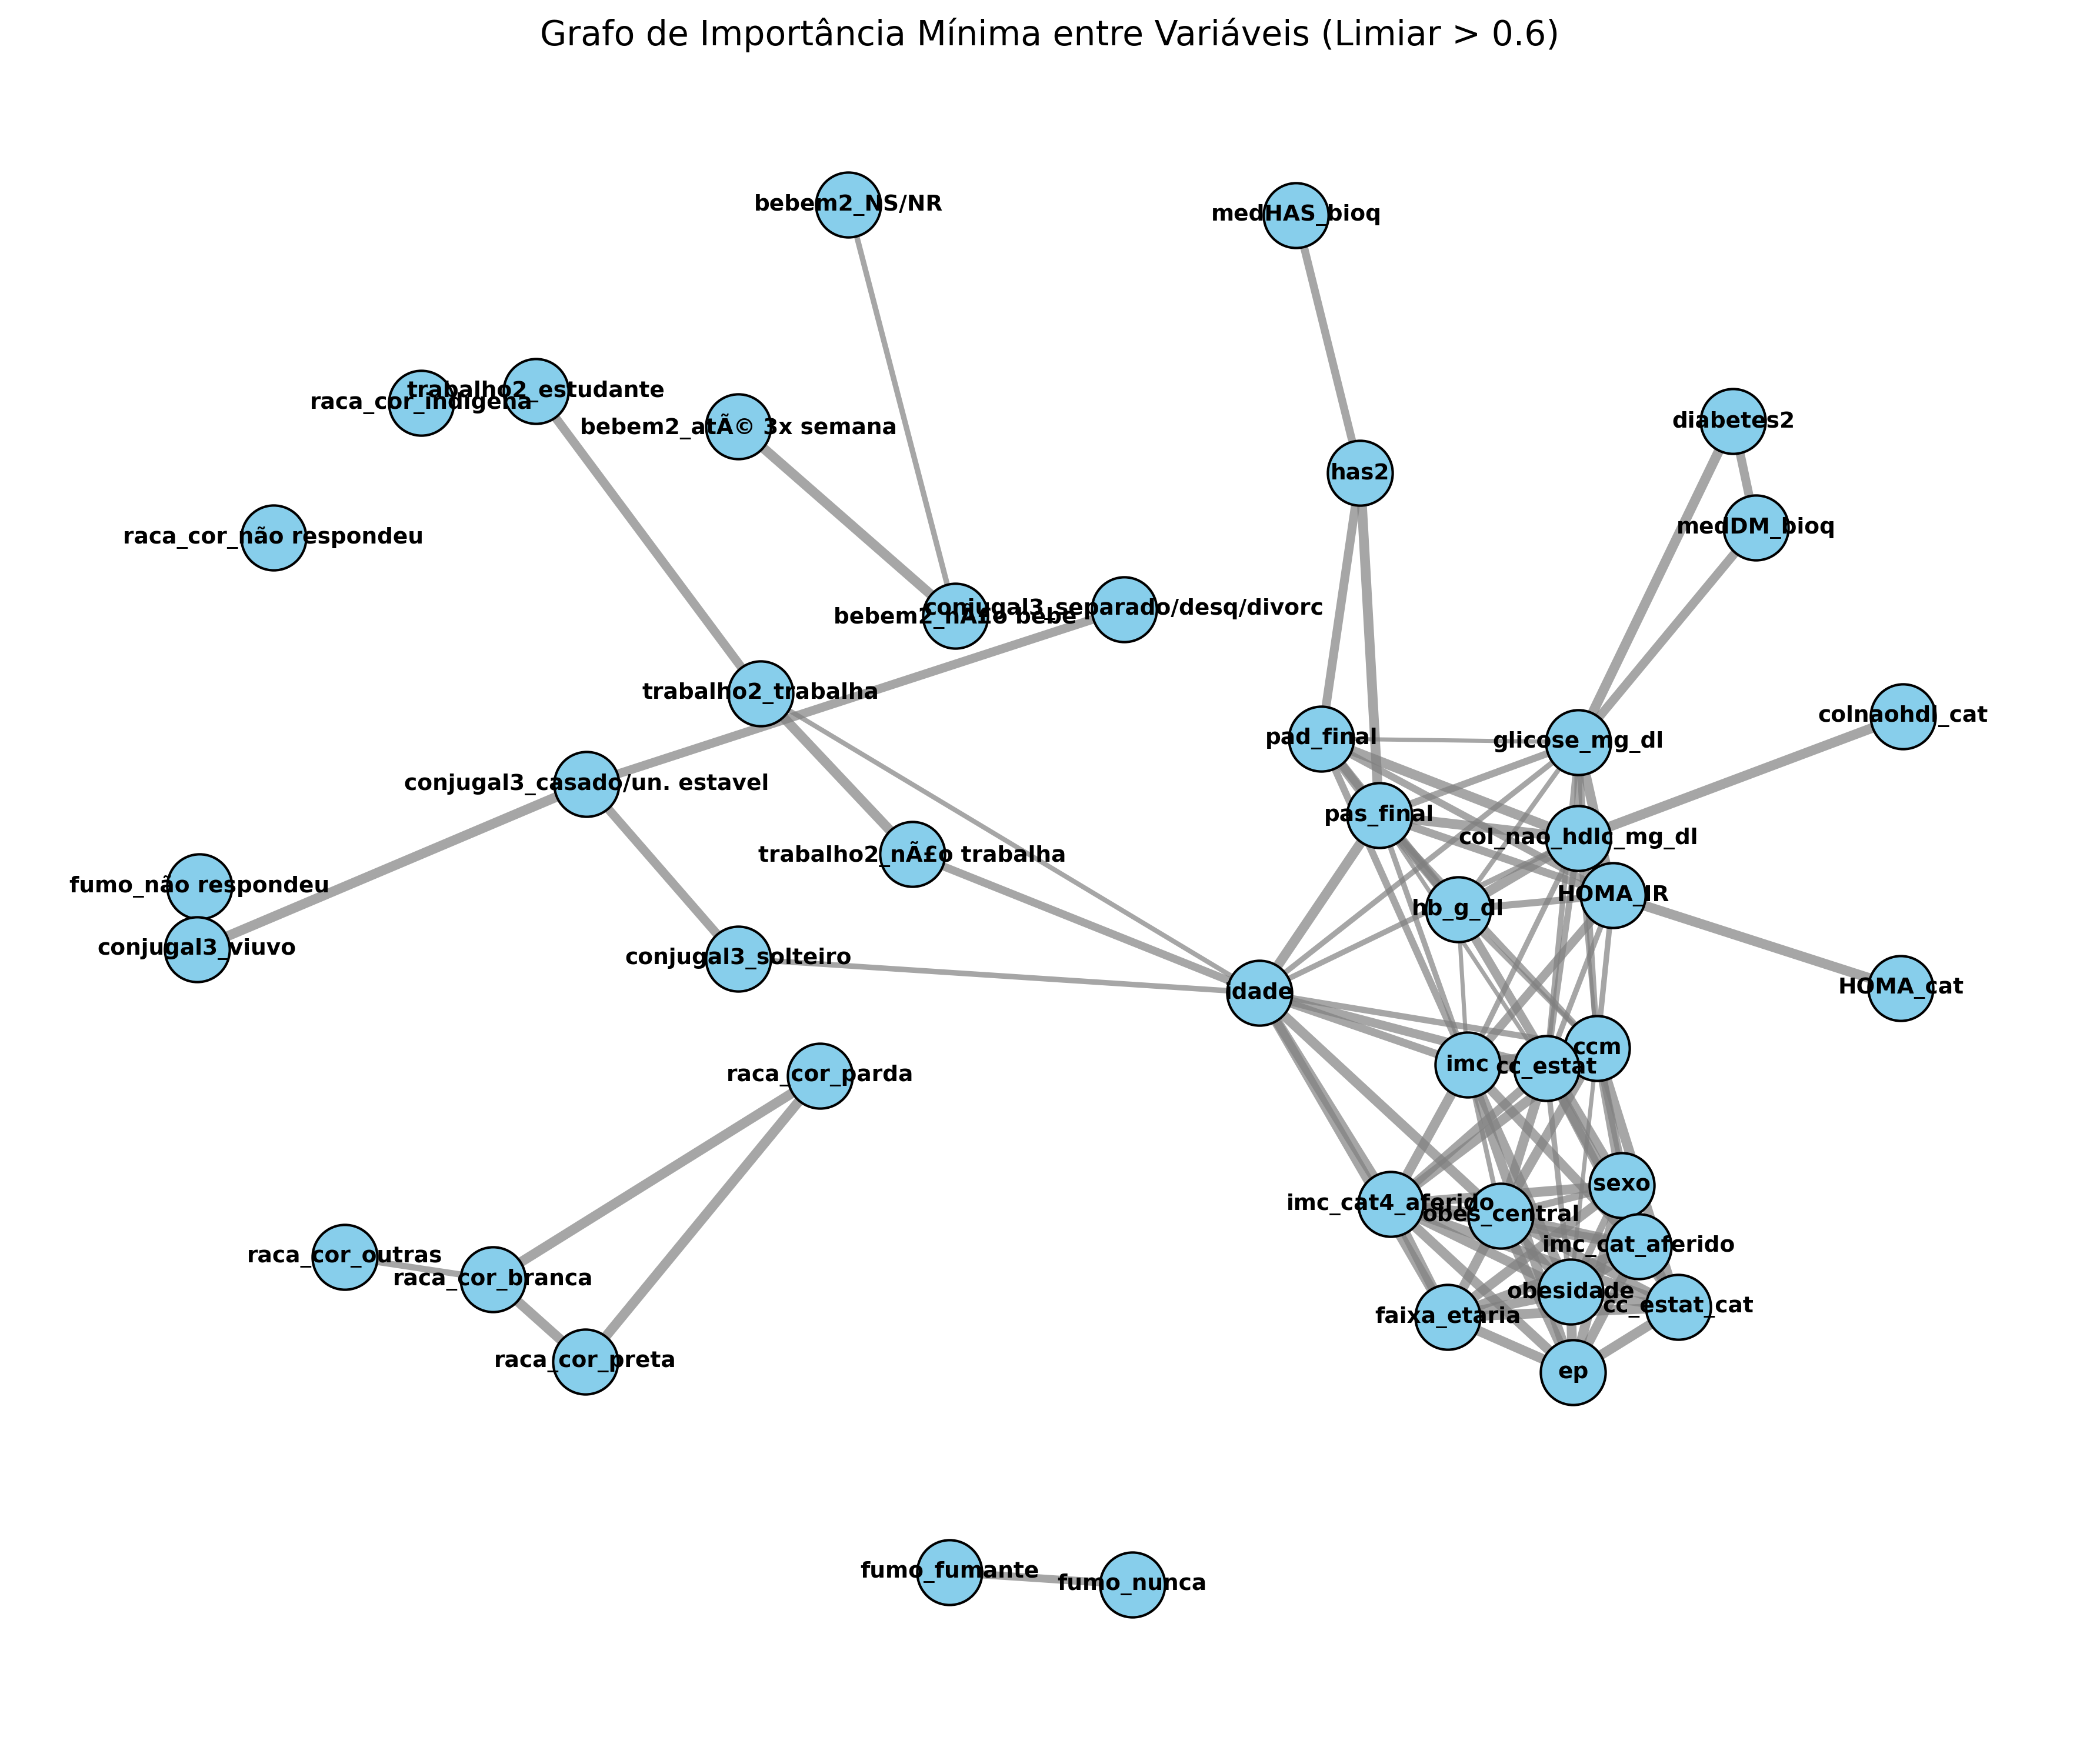

In [40]:
Grafo = nx.from_pandas_adjacency(matriz_final, create_using=nx.Graph)

arestas_para_remover = [
    (u, v)
    for u, v, d in Grafo.edges(data=True)
    if d["weight"] <= IMPORT_MIN
]
Grafo.remove_edges_from(arestas_para_remover)

# Grafo.remove_nodes_from(list(nx.isolates(Grafo)))

# --- ESTILIZAÇÃO DO GRAFO ---
plt.figure(figsize=(12, 10), dpi=300)

pos = nx.spring_layout(Grafo, weight='weight', iterations=150, k = 10/np.sqrt(len(Grafo)))

pesos = np.array([d["weight"] for u, v, d in Grafo.edges(data=True)])

nx.draw_networkx_nodes(
    Grafo, pos, node_size=700, node_color="skyblue", edgecolors="black", 
)

if len(pesos) > 0:
    espessura = ((pesos/pesos.max())*2)**2
else: 
    espessura = 5
nx.draw_networkx_edges(
    Grafo, pos, width=espessura, edge_color="gray", alpha=0.7, arrows=False
)


# Desenha os Nomes das Variáveis
nx.draw_networkx_labels(Grafo, pos, font_size=9, font_weight="bold")

plt.title(
    f"Grafo de Importância Mínima entre Variáveis (Limiar > {IMPORT_MIN})",
    fontsize=14,
)
plt.axis("off")
plt.tight_layout()
plt.savefig('grafo2.png')
plt.show()

In [41]:
# =====================================================================
# 3. CRIANDO A REDE PROBABILÍSTICA (A PONTE PARA A INFERÊNCIA)
# =====================================================================
# Criamos um grafo direcionado apontando as setas na ordem lógica/biológica.
# Usamos apenas conexões que o seu GRaFo provou que são fortes (> 0.75).
Grafo_Direcionado = nx.DiGraph()
Grafo_Direcionado.add_edges_from([
    ('faixa_etaria', 'glicose_mg_dl'), # Idade afetando Glicose
    ('obesidade', 'imc'),              # Obesidade afetando IMC
    ('imc', 'HOMA_IR'),                # IMC afetando Resistência à Insulina
    ('HOMA_IR', 'glicose_mg_dl'),      # HOMA_IR afetando Glicose
    ('imc', 'glicose_mg_dl')           # IMC afetando Glicose diretamente
])

# Inicializamos o modelo de inferência discreta com essas conexões
modelo_inferencia = DiscreteBayesianNetwork(Grafo_Direcionado.edges())

# =====================================================================
# 4. TREINAMENTO AUTOMÁTICO (O Python calcula as probabilidades sozinho!)
# =====================================================================
# O pgmpy vai varrer o seu 'df' real e preencher todas as tabelas 
# de probabilidade condicional (CPDs) cruzando os dados dos seus pacientes.
print("Ajustando o modelo aos dados reais dos pacientes...")
modelo_inferencia.fit(df, estimator=MaximumLikelihoodEstimator)

# =====================================================================
# 5. FAZENDO A INFERÊNCIA (A CONSULTA)
# =====================================================================
# Criamos o motor de inferência exata
motor = VariableElimination(modelo_inferencia)

# Dica: Use 'faixa_etaria' em vez de 'idade' contínua para modelos discretos.
# Verifique no seu 'df' quais são os valores exatos (ex: 0, 1, 2 ou strings) 
# de cada categoria para passar na evidência.

print("\n=== CONSULTA 1: Paciente Sem Obesidade e na Faixa Etária Jovem ===")
resultado_jovem = motor.query(
    variables=['glicose_mg_dl'], 
    evidence={'faixa_etaria': 0, 'obesidade': 0} 
)
print(resultado_jovem)

print("\n=== CONSULTA 2: Paciente Com Obesidade e na Faixa Etária Mais Velha ===")
resultado_idoso = motor.query(
    variables=['glicose_mg_dl'], 
    evidence={'faixa_etaria': 1, 'obesidade': 1}
)
print(resultado_idoso)

Ajustando o modelo aos dados reais dos pacientes...


TypeError: Estimator should be an instance of a discrete parameter estimator. Pass an initialized estimator, for example `DiscreteMLE()`.

In [26]:
matriz_final.to_csv('Matriz.csv')

In [22]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance


def extrair_frequencia_estabilidade_grafo2(
    df, alvos, num_trees=500, iteracoes=50, fracao_amostra=0.5, q=10
):
    """Extrai a frequência de estabilidade das arestas baseado no artigo

    Fellinghauer et al. (2013).

    Parâmetros:
    - q: Número de top variáveis com maior importância que serão selecionadas
         em cada iteração (frequência binária).
    """
    # Matriz inicializada com zeros
    matriz_estabilidade = pd.DataFrame(
        index=alvos, columns=df.columns, dtype=np.float64
    ).fillna(0.0)

    for target in alvos:
        print(f"Rodando a variável {target}")
        df_alvo = df.dropna(subset=[target])

        for i in range(iteracoes):
            if fracao_amostra > 1:
                df_sub = df_alvo.sample(n=fracao_amostra, random_state=i)
            else:
                df_sub = df_alvo.sample(frac=fracao_amostra, random_state=i)
            

            X = df_sub.drop(columns=[target])
            y = df_sub[target]

            if target not in colunas_categoricas:
                modelorf = RandomForestRegressor(
                    n_estimators=num_trees,
                    max_features=0.3,
                    max_depth=8,
                    n_jobs = -1,
                    bootstrap=True,
                )
            else:
                modelorf = RandomForestClassifier(
                    n_estimators=num_trees,
                    max_features=0.3,
                    max_depth=8,
                    class_weight='balanced',
                    bootstrap=True, # Bootstrap ligado e 1 iteracao, e 100% dos dados
                    n_jobs = -1,
                )

            modelorf.fit(X, y)

            resultado_permutacao = permutation_importance(
                modelorf, X, y, n_repeats=3, random_state=i, n_jobs=-1
            )
            importancias = resultado_permutacao.importances_mean

            importancias_series = pd.Series(importancias, index=X.columns)

            top_q_variaveis = importancias_series.nlargest(q).index

            matriz_estabilidade.loc[target, top_q_variaveis] += 1.0

        matriz_estabilidade.loc[target] = (
            matriz_estabilidade.loc[target] / iteracoes
        )

    return matriz_estabilidade

In [23]:
matriz2 = extrair_frequencia_estabilidade_grafo2(df,df.columns,500,1,1.0,10)

Rodando a variável hb_g_dl
Rodando a variável glicose_mg_dl
Rodando a variável sexo
Rodando a variável idade
Rodando a variável faixa_etaria
Rodando a variável imc
Rodando a variável imc_cat4_aferido
Rodando a variável imc_cat_aferido
Rodando a variável ep
Rodando a variável obesidade
Rodando a variável ccm
Rodando a variável obes_central
Rodando a variável cc_estat
Rodando a variável cc_estat_cat
Rodando a variável medDM_bioq
Rodando a variável diabetes2
Rodando a variável HOMA_IR
Rodando a variável HOMA_cat
Rodando a variável pas_final
Rodando a variável pad_final
Rodando a variável medHAS_bioq
Rodando a variável has2
Rodando a variável col_nao_hdlc_mg_dl
Rodando a variável colnaohdl_cat
Rodando a variável fumo_fumante
Rodando a variável fumo_nunca
Rodando a variável fumo_não respondeu
Rodando a variável raca_cor_branca
Rodando a variável raca_cor_indígena
Rodando a variável raca_cor_não respondeu
Rodando a variável raca_cor_outras
Rodando a variável raca_cor_parda
Rodando a variável

In [30]:
matriz_numpy = matriz2.to_numpy()

matriz_min = np.minimum(matriz_numpy,matriz_numpy.T)

matriz_final2 = pd.DataFrame(
    matriz_min, index=matriz2.index, columns=matriz2.columns
)

In [31]:
matriz_final2

,hb_g_dl,glicose_mg_dl,sexo,idade,faixa_etaria,imc,imc_cat4_aferido,imc_cat_aferido,ep,obesidade,...,conjugal3_casado/un. estavel,conjugal3_separado/desq/divorc,conjugal3_solteiro,conjugal3_viuvo,trabalho2_estudante,trabalho2_nÃ£o trabalha,trabalho2_trabalha,bebem2_NS/NR,bebem2_atÃ© 3x semana,bebem2_nÃ£o bebe
hb_g_dl,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
glicose_mg_dl,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sexo,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
idade,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
faixa_etaria,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
imc,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
imc_cat4_aferido,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
imc_cat_aferido,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ep,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
obesidade,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


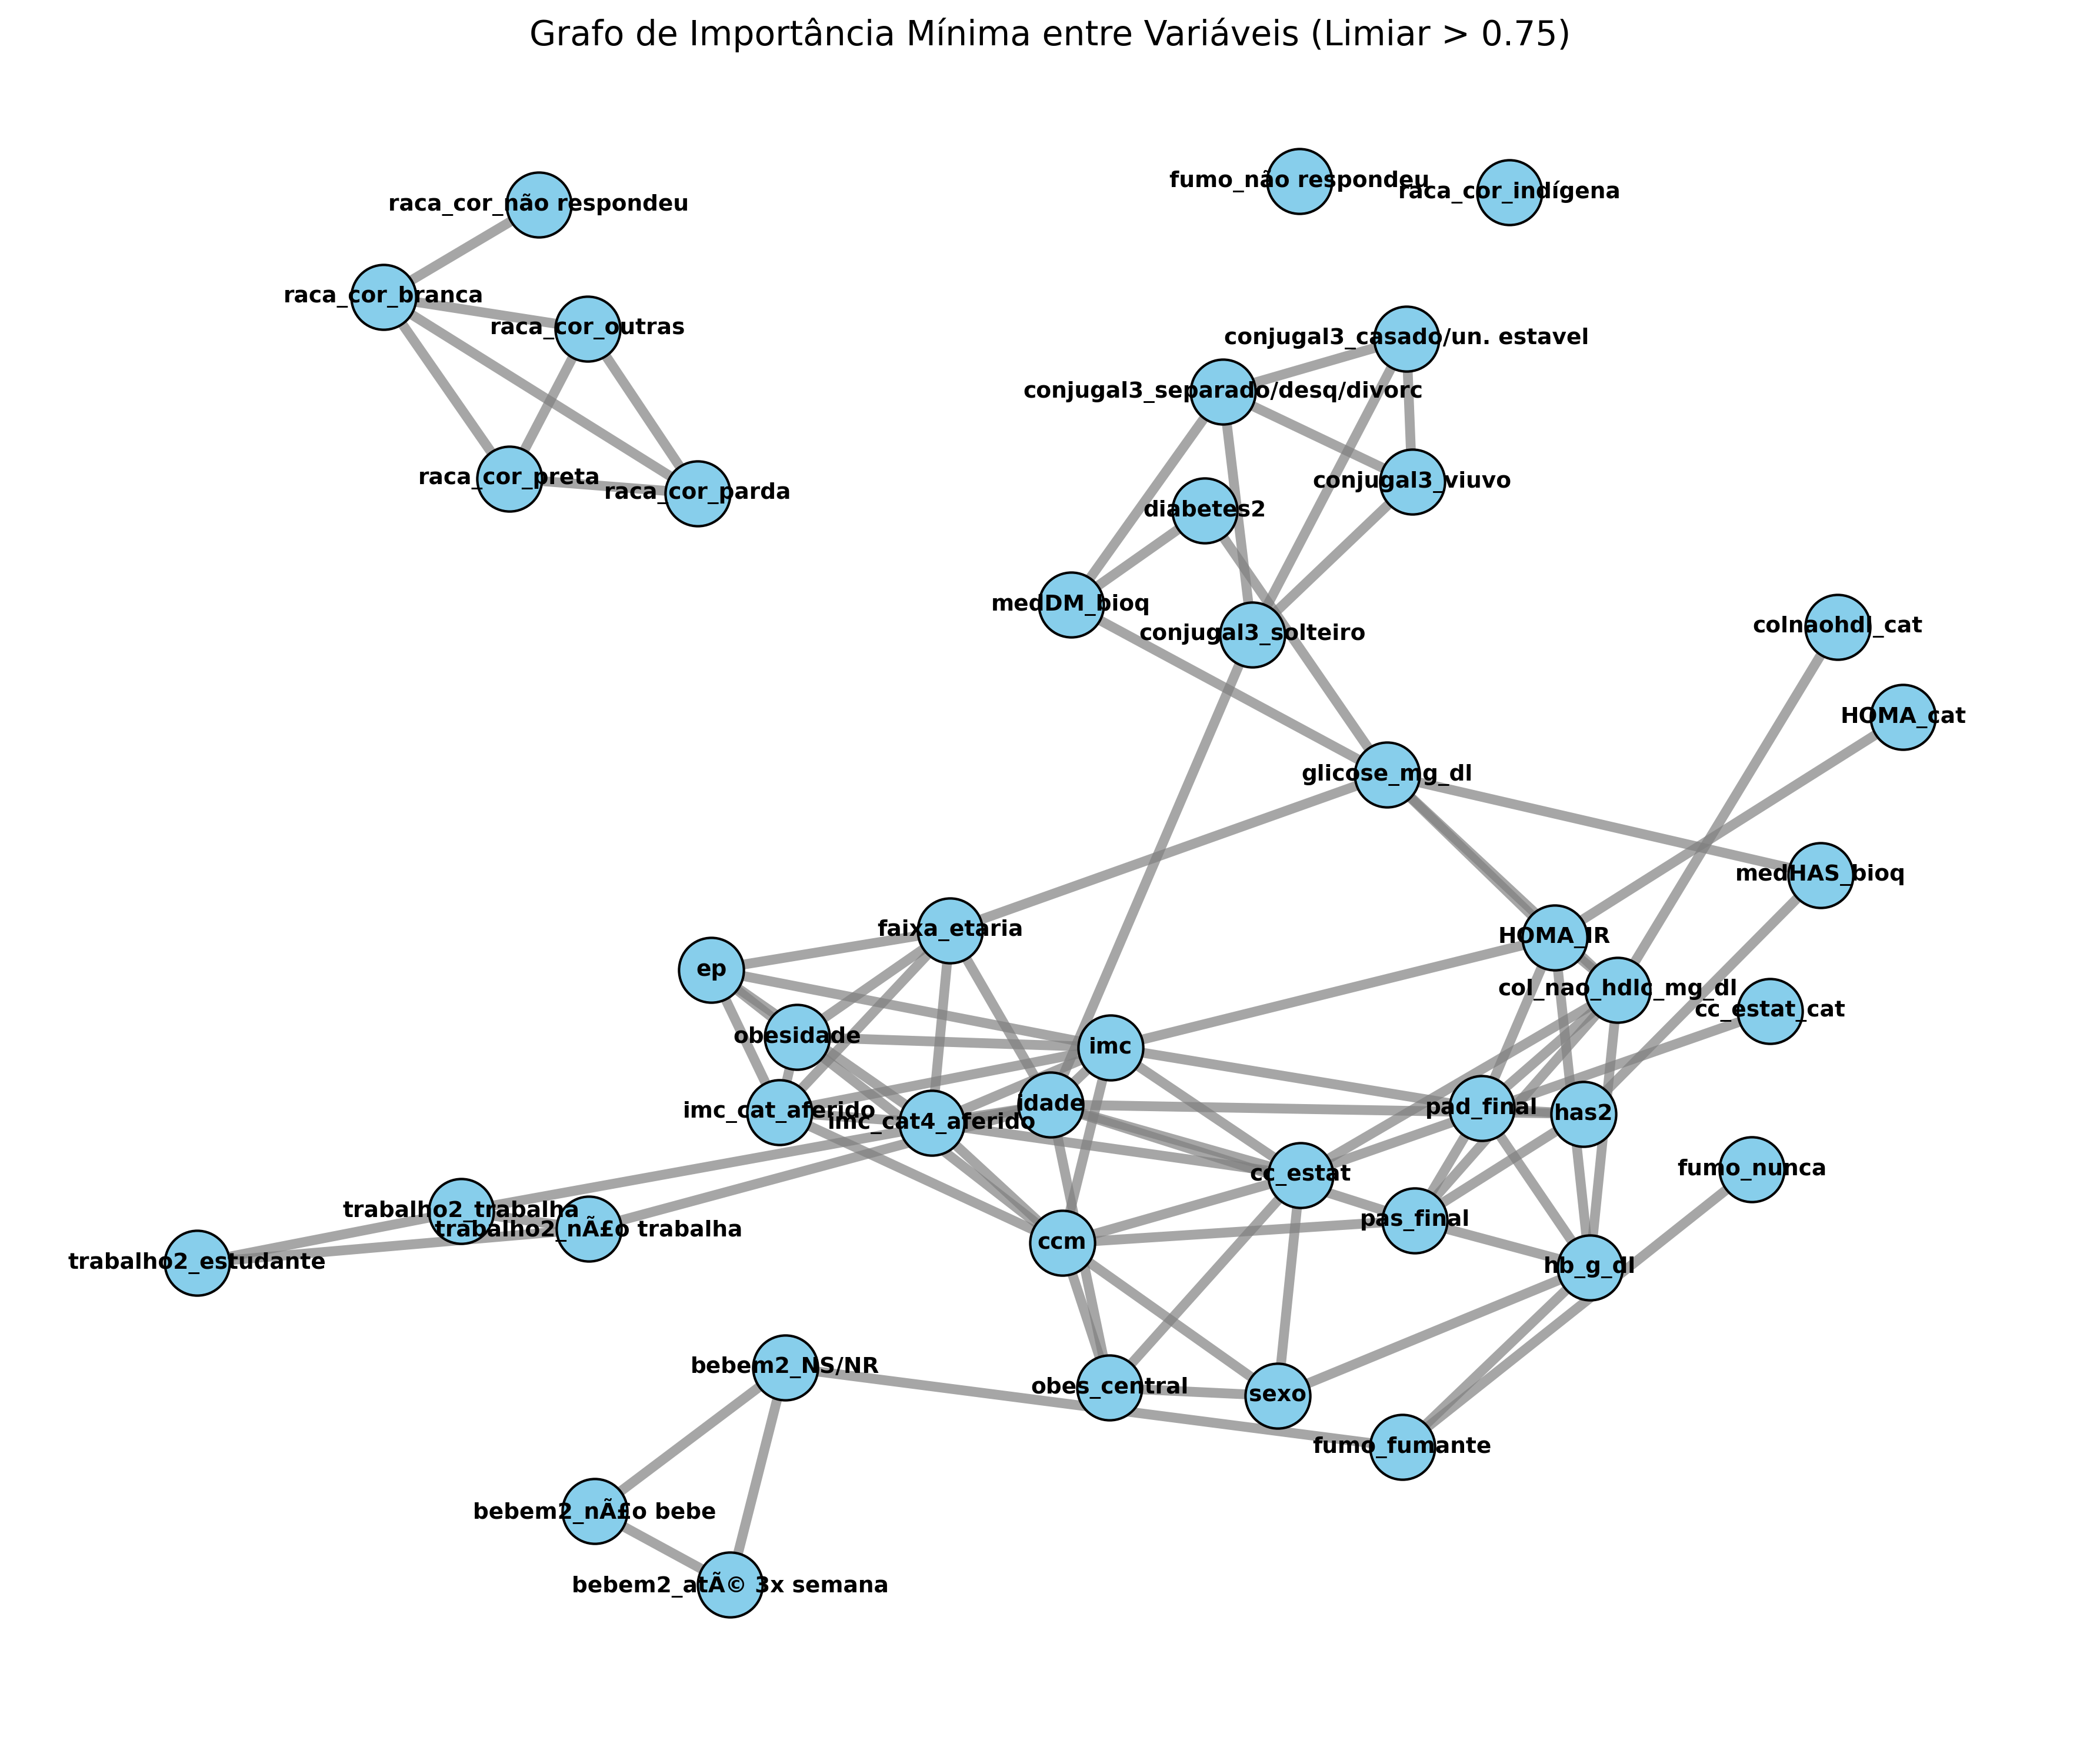

In [32]:
Grafo = nx.from_pandas_adjacency(matriz_final2, create_using=nx.Graph)

arestas_para_remover = [
    (u, v)
    for u, v, d in Grafo.edges(data=True)
    if d["weight"] <= IMPORT_MIN
]
Grafo.remove_edges_from(arestas_para_remover)

# Grafo.remove_nodes_from(list(nx.isolates(Grafo)))

# --- ESTILIZAÇÃO DO GRAFO ---
plt.figure(figsize=(12, 10), dpi=300)

pos = nx.spring_layout(Grafo, weight='weight', iterations=150, k = 10/np.sqrt(len(Grafo)))

pesos = np.array([d["weight"] for u, v, d in Grafo.edges(data=True)])

nx.draw_networkx_nodes(
    Grafo, pos, node_size=700, node_color="skyblue", edgecolors="black", 
)

if len(pesos) > 0:
    espessura = ((pesos/pesos.max())*2)**2
else: 
    espessura = 5
nx.draw_networkx_edges(
    Grafo, pos, width=espessura, edge_color="gray", alpha=0.7, arrows=False
)


# Desenha os Nomes das Variáveis
nx.draw_networkx_labels(Grafo, pos, font_size=9, font_weight="bold")

plt.title(
    f"Grafo de Importância Mínima entre Variáveis (Limiar > {IMPORT_MIN})",
    fontsize=14,
)
plt.axis("off")
plt.tight_layout()
plt.show()